<a href="https://colab.research.google.com/github/NidhiDekate/car-price-multimodal-dl/blob/main/05_CNN_branch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 05 — CNN Branch

## Goal
Train a CNN that predicts car price from a car image alone.
This is one branch of our final multimodal model.

---

## What this notebook does
1. Connects each row in our dataframe to an actual car image
2. Builds a PyTorch Dataset class to feed images into the model
3. Uses ResNet18 (pretrained CNN) as our backbone
4. Trains CNN-only model → image → predicted price
5. Evaluates performance and saves model weights for notebook 06

---

## The data connection problem (and how we solved it)

Our dataframe has 40,658 rows. Each row is a car sale with a price.
But our CNN needs an actual image — not just a class name.

**Three files helped us solve this:**

| File | What it contains |
|---|---|
| `cars_train_annos.mat` | filename → class index (e.g. 00001.jpg → class 14) |
| `cars_meta.mat` | class index → class name (e.g. 14 → "BMW 3 Series Sedan 2012") |
| `cars_train/` | actual .jpg images |



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

base   = '/content/drive/MyDrive/CarPricePrediction/'
img_dir = base + 'data/images/'

df = pd.read_csv(base + 'data/tabular/df_matched.csv')
print("shape:", df.shape)
print("columns:", df.columns.tolist())

Mounted at /content/drive
shape: (40658, 17)
columns: ['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate', 'stanford_class']


In [ ]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,stanford_class
0,2012,Acura,Tsx,Base,Sedan,automatic,jh4cu2f43cc007761,ca,39.0,43127.0,black,black,ahfc/honda lease trust/hvt inc. eot,16450.0,17800.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),Acura TSX Sedan 2012
1,2012,Bmw,3 Series,335is,Convertible,automatic,wbadx1c56ce570700,ca,38.0,14149.0,black,black,financial services remarketing (lease),39900.0,40500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST),BMW 3 Series Sedan 2012
2,2012,Bmw,3 Series,328i,Convertible,automatic,wbadw7c5xce729000,ca,31.0,27675.0,blue,gray,financial services remarketing (lease),28200.0,25750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST),BMW 3 Series Sedan 2012
3,2012,Bmw,1 Series,135i,Coupe,automatic,wbauc9c56cvm12464,ca,41.0,16288.0,blue,—,financial services remarketing (lease),26900.0,27500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST),BMW 1 Series Convertible 2012
4,2012,Acura,Tl,Base,Sedan,automatic,19uua8f23ca002640,ca,41.0,28395.0,gray,black,ahfc/honda lease trust/hvt inc. eot,19200.0,20200.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),Acura TL Sedan 2012


In [ ]:
# check image folders
devkit_path = img_dir + 'car_devkit/'
test_path   = img_dir + 'cars_test/'

print("devkit contents:", os.listdir(devkit_path))
print("\ntest folder exists:", os.path.exists(test_path))

# count images in cars_test
all_images = []
for root, dirs, files in os.walk(test_path):
    for f in files:
        if f.endswith('.jpg'):
            all_images.append(os.path.join(root, f))

print(f"total images found: {len(all_images)}")
print("sample path:", all_images[0] if all_images else "none")

devkit contents: ['devkit']

test folder exists: True
total images found: 5956
sample path: /content/drive/MyDrive/CarPricePrediction/data/images/cars_test/cars_test/01879.jpg


In [ ]:
# check what stanford_class looks like in our matched data
print("stanford_class sample values:")
print(df['stanford_class'].value_counts().head(10))
print()
print("unique classes:", df['stanford_class'].nunique())
print("any nulls:", df['stanford_class'].isnull().sum())

# check what's inside cars_test_annos.mat
import scipy.io
anno_path = img_dir + 'car_devkit/devkit/cars_test_annos.mat'
annos = scipy.io.loadmat(anno_path)
print()
print("annotation keys:", list(annos.keys()))
print("sample annotation:", annos['annotations'][0][0])

stanford_class sample values:
stanford_class
Honda Accord Coupe 2012                   3198
Toyota Camry Sedan 2012                   2983
Hyundai Sonata Hybrid Sedan 2012          1959
Ford F-150 Regular Cab 2012               1940
Mercedes-Benz C-Class Sedan 2012          1517
Ford Edge SUV 2012                        1285
BMW 3 Series Sedan 2012                   1275
Hyundai Elantra Touring Hatchback 2012     998
Honda Odyssey Minivan 2012                 989
Toyota Corolla Sedan 2012                  962
Name: count, dtype: int64

unique classes: 141
any nulls: 0

annotation keys: ['__header__', '__version__', '__globals__', 'annotations']
sample annotation: (array([[30]], dtype=uint8), array([[52]], dtype=uint8), array([[246]], dtype=uint8), array([[147]], dtype=uint8), array(['00001.jpg'], dtype='<U9'))


In [ ]:
import scipy.io

# load class names from meta
meta = scipy.io.loadmat(img_dir + 'car_devkit/devkit/cars_meta.mat')
class_names = [str(c[0]) for c in meta['class_names'][0]]

print(f"total classes in meta: {len(class_names)}")
print("sample:", class_names[:5])
print()

# check if our stanford_class values match meta class names
our_classes = set(df['stanford_class'].unique())
meta_classes = set(class_names)

matched   = our_classes & meta_classes
unmatched = our_classes - meta_classes

print(f"our classes:          {len(our_classes)}")
print(f"found in meta:        {len(matched)}")
print(f"NOT found in meta:    {len(unmatched)}")
if unmatched:
    print("unmatched examples:", list(unmatched)[:5])

total classes in meta: 196
sample: ['AM General Hummer SUV 2000', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008', 'Acura TSX Sedan 2012']

our classes:          141
found in meta:        141
NOT found in meta:    0


In [ ]:
# load train annotations - these have class labels
train_annos = scipy.io.loadmat(img_dir + 'car_devkit/devkit/cars_train_annos.mat')
sample = train_annos['annotations'][0][0]
print("train annotation sample:", sample)
print("fields per annotation:", len(sample))

train annotation sample: (array([[39]], dtype=uint8), array([[116]], dtype=uint8), array([[569]], dtype=uint16), array([[375]], dtype=uint16), array([[14]], dtype=uint8), array(['00001.jpg'], dtype='<U9'))
fields per annotation: 6


In [ ]:
import zipfile

zip_path = img_dir + 'archive.zip'

# peek inside zip without extracting
with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    print(f"total files in zip: {len(all_files)}")
    print("\nfirst 20 files:")
    for f in all_files[:20]:
        print(" ", f)
    print("\n...")
    print("last 10 files:")
    for f in all_files[-10:]:
        print(" ", f)

total files in zip: 16191

first 20 files:
  car_devkit/devkit/README.txt
  car_devkit/devkit/cars_meta.mat
  car_devkit/devkit/cars_test_annos.mat
  car_devkit/devkit/cars_train_annos.mat
  car_devkit/devkit/eval_train.m
  car_devkit/devkit/train_perfect_preds.txt
  cars_test/cars_test/00001.jpg
  cars_test/cars_test/00002.jpg
  cars_test/cars_test/00003.jpg
  cars_test/cars_test/00004.jpg
  cars_test/cars_test/00005.jpg
  cars_test/cars_test/00006.jpg
  cars_test/cars_test/00007.jpg
  cars_test/cars_test/00008.jpg
  cars_test/cars_test/00009.jpg
  cars_test/cars_test/00010.jpg
  cars_test/cars_test/00011.jpg
  cars_test/cars_test/00012.jpg
  cars_test/cars_test/00013.jpg
  cars_test/cars_test/00014.jpg

...
last 10 files:
  cars_train/cars_train/08135.jpg
  cars_train/cars_train/08136.jpg
  cars_train/cars_train/08137.jpg
  cars_train/cars_train/08138.jpg
  cars_train/cars_train/08139.jpg
  cars_train/cars_train/08140.jpg
  cars_train/cars_train/08141.jpg
  cars_train/cars_train/0814

In [ ]:
import zipfile

zip_path = img_dir + 'archive.zip'
extract_path = img_dir

# only extract cars_train images - skip what we already have
print("extracting cars_train images...")

with zipfile.ZipFile(zip_path, 'r') as z:
    train_files = [f for f in z.namelist() if f.startswith('cars_train/')]
    print(f"files to extract: {len(train_files)}")

    for i, f in enumerate(train_files):
        z.extract(f, extract_path)
        if (i+1) % 1000 == 0:
            print(f"  extracted {i+1}/{len(train_files)}")

print("done")
print("checking:", os.path.exists(img_dir + 'cars_train/cars_train/00001.jpg'))

extracting cars_train images...
files to extract: 8144
  extracted 1000/8144
  extracted 2000/8144
  extracted 3000/8144
  extracted 4000/8144
  extracted 5000/8144
  extracted 6000/8144
  extracted 7000/8144
  extracted 8000/8144
done
checking: True


In [ ]:
# build class index → list of image paths mapping
train_anno_path = img_dir + 'car_devkit/devkit/cars_train_annos.mat'
train_annos = scipy.io.loadmat(train_anno_path)

# parse all annotations
# each annotation: (x1, y1, x2, y2, class_index, filename)
class_to_images = {}  # class_index (1-196) → list of image paths

train_img_dir = img_dir + 'cars_train/cars_train/'

for anno in train_annos['annotations'][0]:
    class_idx = int(anno[4][0][0])   # 1-indexed
    filename  = str(anno[5][0])
    img_path  = train_img_dir + filename

    if class_idx not in class_to_images:
        class_to_images[class_idx] = []
    class_to_images[class_idx].append(img_path)

print(f"total classes mapped: {len(class_to_images)}")
print(f"sample - class 1 ({class_names[0]}): {len(class_to_images[1])} images")
print(f"sample - class 2 ({class_names[1]}): {len(class_to_images[2])} images")

# check images per class distribution
counts = [len(v) for v in class_to_images.values()]
print(f"\nimages per class — min: {min(counts)}, max: {max(counts)}, avg: {np.mean(counts):.1f}")

total classes mapped: 196
sample - class 1 (AM General Hummer SUV 2000): 45 images
sample - class 2 (Acura RL Sedan 2012): 32 images

images per class — min: 24, max: 68, avg: 41.6


In [ ]:
# map class NAME → image paths
# class_names list is 0-indexed, but class_idx in annotations is 1-indexed
# so class_names[0] = class index 1

classname_to_images = {}

for class_idx, img_paths in class_to_images.items():
    name = class_names[class_idx - 1]  # convert 1-indexed to 0-indexed
    classname_to_images[name] = img_paths

print(f"total class names mapped: {len(classname_to_images)}")
print()

# verify our df classes are all covered
our_classes = df['stanford_class'].unique()
missing = [c for c in our_classes if c not in classname_to_images]

print(f"our df classes:     {len(our_classes)}")
print(f"missing from map:   {len(missing)}")
if missing:
    print("missing:", missing)
else:
    print("all classes covered — ready to build dataset")

total class names mapped: 196

our df classes:     141
missing from map:   0
all classes covered — ready to build dataset


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import random

class CarDataset(Dataset):
    def __init__(self, df, classname_to_images, transform=None):
        self.df                  = df.reset_index(drop=True)
        self.classname_to_images = classname_to_images
        self.transform           = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # get a random image for this car's class
        class_name  = row['stanford_class']
        img_paths   = self.classname_to_images[class_name]
        img_path    = random.choice(img_paths)

        # load and transform image
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # target - log price (same as notebook 04)
        price = torch.tensor(np.log1p(row['sellingprice']), dtype=torch.float32)

        return image, price

print("CarDataset class defined")

CarDataset class defined


In [ ]:
# recreate df splits - same logic as notebook 03
from sklearn.model_selection import train_test_split

# start from full matched df
# first split: 70% train, 30% temp
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

# second split: 50/50 on temp → 15% val, 15% test
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"train: {len(train_df)} rows")
print(f"val:   {len(val_df)} rows")
print(f"test:  {len(test_df)} rows")

# save for future notebooks
train_df.to_csv(base + 'data/tabular/train_df.csv', index=False)
val_df.to_csv(base + 'data/tabular/val_df.csv', index=False)
test_df.to_csv(base + 'data/tabular/test_df.csv', index=False)
print("saved")

train: 28460 rows
val:   6099 rows
test:  6099 rows
saved


In [ ]:
# transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# create dataset objects
train_dataset = CarDataset(train_df, classname_to_images, train_transform)
val_dataset   = CarDataset(val_df,   classname_to_images, val_transform)
test_dataset  = CarDataset(test_df,  classname_to_images, val_transform)

print(f"train dataset size: {len(train_dataset)}")
print(f"val dataset size:   {len(val_dataset)}")
print(f"test dataset size:  {len(test_dataset)}")

# test one sample
image, price = train_dataset[0]

train dataset size: 28460
val dataset size:   6099
test dataset size:  6099


In [ ]:
image, price = train_dataset[0]
print(f"image shape: {image.shape}")
print(f"price (log): {price.item():.4f}")
print(f"price ($):   ${np.expm1(price.item()):,.0f}")

image shape: torch.Size([3, 224, 224])
price (log): 8.6997
price ($):   $6,000


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"train batches: {len(train_loader)}")
print(f"val batches:   {len(val_loader)}")
print(f"test batches:  {len(test_loader)}")

train batches: 890
val batches:   191
test batches:  191


In [ ]:
import torch.nn as nn
from torchvision import models

def build_cnn_model():
    # load pretrained resnet18
    model = models.resnet18(weights='IMAGENET1K_V1')

    # freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # replace final layer
    # original resnet18 final layer: 512 inputs → 1000 outputs (imagenet classes)
    # ours: 512 inputs → 1 output (car price)
    model.fc = nn.Sequential(
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1)
    )

    return model

model = build_cnn_model()

# check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

model = model.to(device)

# count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"total parameters:     {total_params:,}")
print(f"trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


device: cuda
total parameters:     11,308,097
trainable parameters: 131,585


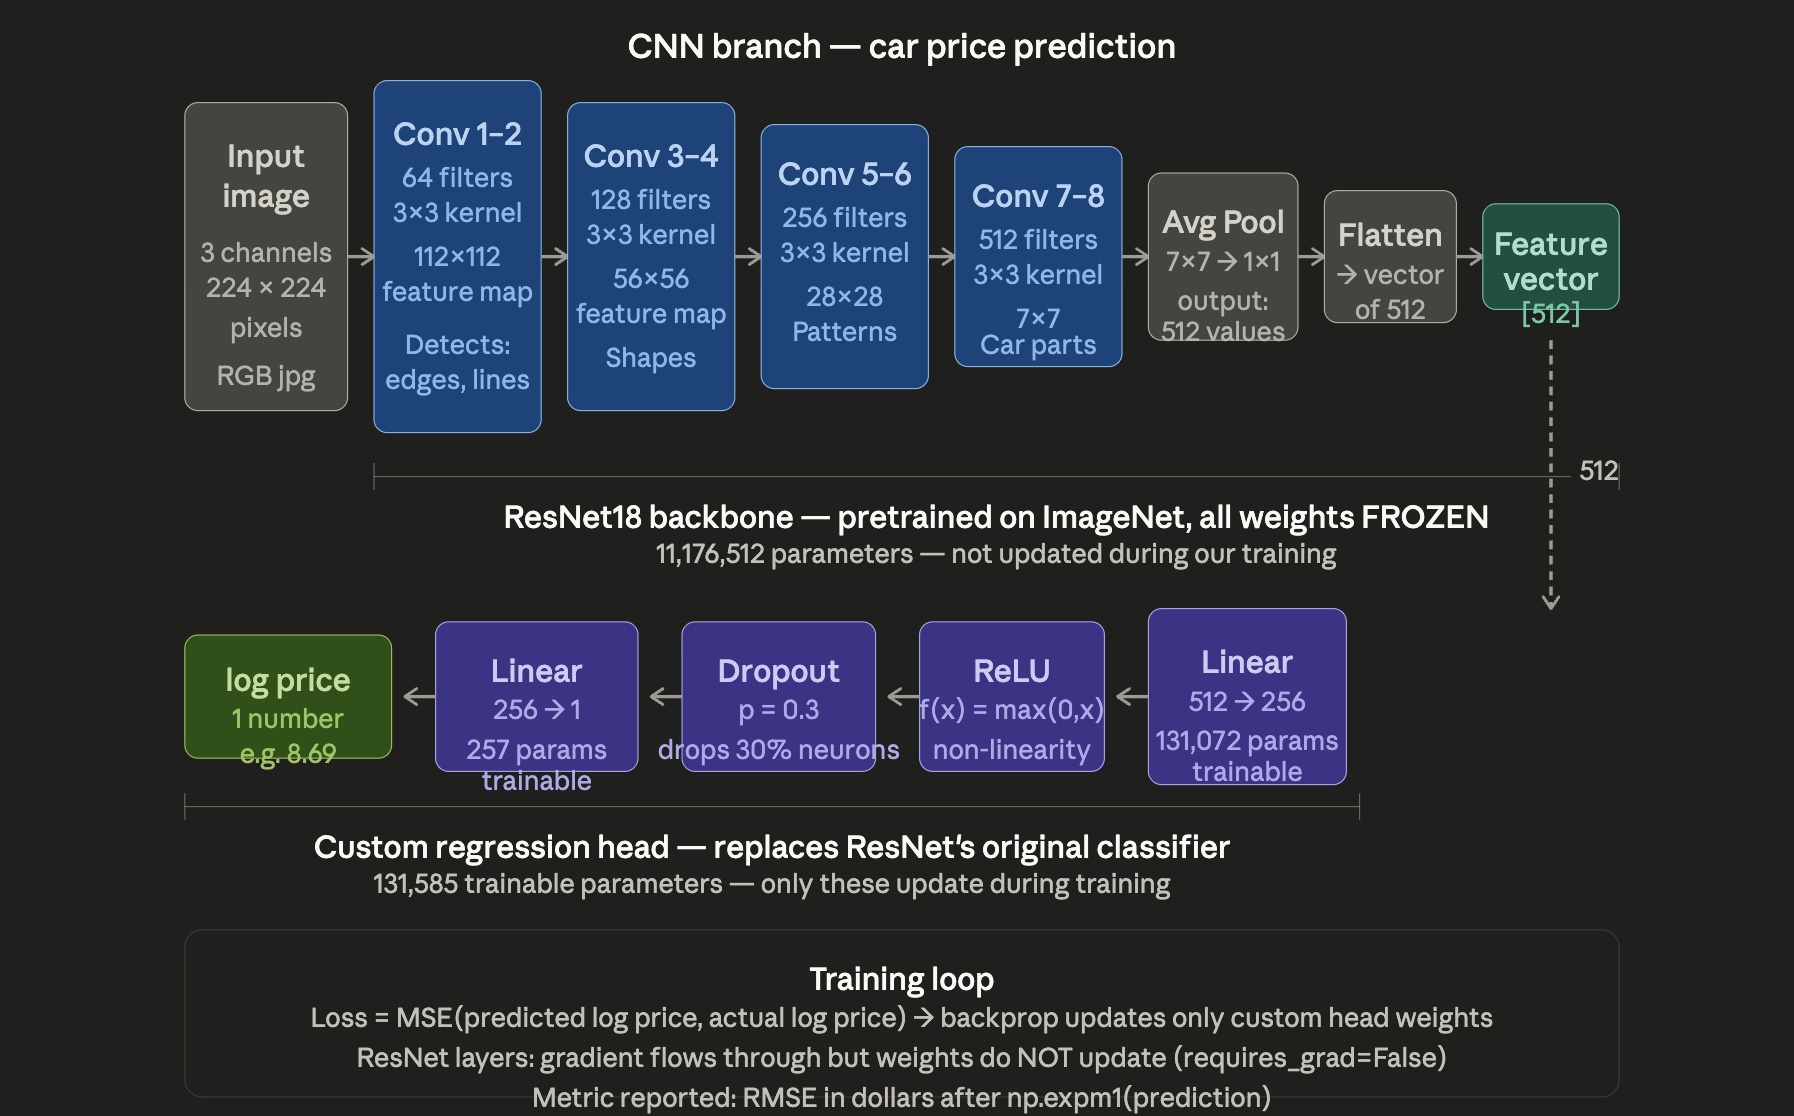

In [ ]:
import torch.optim as optim

# loss function
criterion = nn.MSELoss()

# optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

# learning rate scheduler - reduce lr when val loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print("criterion:", criterion)
print("optimizer:", optimizer)

criterion: MSELoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for images, prices in loader:
        images = images.to(device)
        prices = prices.to(device).unsqueeze(1)

        optimizer.zero_grad()
        preds = model(images)
        loss  = criterion(preds, prices)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, prices in loader:
            images = images.to(device)
            prices = prices.to(device).unsqueeze(1)

            preds     = model(images)
            loss      = criterion(preds, prices)
            total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


print("training functions defined")

training functions defined


In [ ]:
# copy images to colab local disk first - much faster than drive
import shutil

local_img_dir = '/content/cars_train/'

if not os.path.exists(local_img_dir):
    print("copying images from drive to local disk...")
    shutil.copytree(
        base + 'data/images/cars_train/cars_train/',
        local_img_dir
    )
    print("done!")
else:
    print("already copied")

print("total images:", len(os.listdir(local_img_dir)))

copying images from drive to local disk...
done!
total images: 8144


In [ ]:
# rebuild lookup with local paths
local_classname_to_images = {}

for class_idx, img_paths in class_to_images.items():
    name = class_names[class_idx - 1]
    local_paths = [p.replace(base + 'data/images/cars_train/cars_train/', '/content/cars_train/') for p in img_paths]
    local_classname_to_images[name] = local_paths

# recreate datasets with local paths
train_dataset = CarDataset(train_df, local_classname_to_images, train_transform)
val_dataset   = CarDataset(val_df,   local_classname_to_images, val_transform)
test_dataset  = CarDataset(test_df,  local_classname_to_images, val_transform)

# recreate dataloaders with more workers now that disk is fast
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# verify one sample loads
image, price = train_dataset[0]
print("sample image shape:", image.shape)
print("train batches:", len(train_loader))
print("ready to train!")

sample image shape: torch.Size([3, 224, 224])
train batches: 445
ready to train!


In [ ]:
# reset model fresh before retraining
model = build_cnn_model().to(device)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

epochs       = 15
best_val     = float('inf')
train_losses = []
val_losses   = []

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), base + 'models/cnn_best.pth')
        tag = '  ← best'
    else:
        tag = ''

    print(f"epoch {epoch:02d}/{epochs}  train: {train_loss:.4f}  val: {val_loss:.4f}{tag}")

print(f"\ntraining done — best val loss: {best_val:.4f}")

epoch 01/15  train: 1.8474  val: 0.6809  ← best
epoch 02/15  train: 0.9745  val: 0.5779  ← best
epoch 03/15  train: 0.9395  val: 0.5521  ← best
epoch 04/15  train: 0.9071  val: 0.5192  ← best
epoch 05/15  train: 0.8892  val: 0.5017  ← best
epoch 06/15  train: 0.8473  val: 0.5460
epoch 07/15  train: 0.8476  val: 0.5466
epoch 08/15  train: 0.8170  val: 0.4694  ← best
epoch 09/15  train: 0.8127  val: 0.4701
epoch 10/15  train: 0.8096  val: 0.4570  ← best
epoch 11/15  train: 0.7630  val: 0.4654
epoch 12/15  train: 0.7653  val: 0.4481  ← best
epoch 13/15  train: 0.7324  val: 0.4384  ← best
epoch 14/15  train: 0.7327  val: 0.4422
epoch 15/15  train: 0.7023  val: 0.4237  ← best

training done — best val loss: 0.4237


In [ ]:
from sklearn.metrics import r2_score

model.eval()
all_preds  = []
all_actual = []

with torch.no_grad():
    for images, prices in val_loader:
        images = images.to(device)
        preds  = model(images).squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_actual.extend(prices.numpy())

all_preds  = np.array(all_preds)
all_actual = np.array(all_actual)

# convert from log scale back to dollars
preds_dollars  = np.expm1(all_preds)
actual_dollars = np.expm1(all_actual)

rmse = np.sqrt(np.mean((preds_dollars - actual_dollars) ** 2))
r2   = r2_score(actual_dollars, preds_dollars)

print(f"CNN val RMSE: ${rmse:,.0f}")
print(f"CNN val R²:   {r2:.4f}")
print()
print(f"XGBoost val RMSE: $1,872  R²: 0.9500")
print(f"CNN only    RMSE: ${rmse:,.0f}  R²: {r2:.4f}")

CNN val RMSE: $10,454
CNN val R²:   -0.4912

XGBoost val RMSE: $1,872  R²: 0.9500
CNN only    RMSE: $10,454  R²: -0.4912


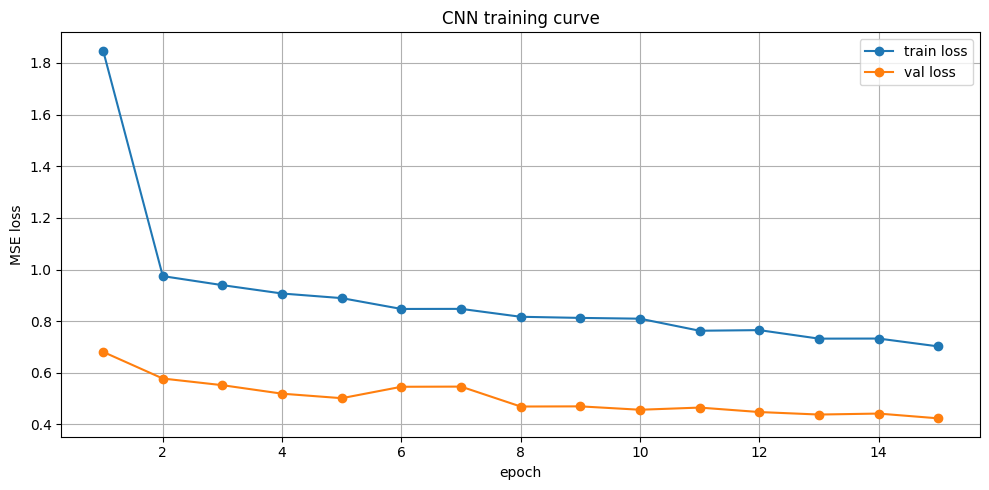

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), train_losses, label='train loss', marker='o')
plt.plot(range(1, epochs+1), val_losses,   label='val loss',   marker='o')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('CNN training curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Results — CNN branch

### Performance vs XGBoost

| Model | RMSE | R² |
|---|---|---|
| XGBoost (tabular only) | $1,872 | 0.95 |
| CNN (images only) | $10,454 | -0.49 |

### Why CNN underperforms — and why that's expected

CNN sees only pixels — body shape, color, size.
CNN cannot see odometer, condition, or year — the primary price drivers.

A car image literally cannot tell you if a vehicle has 20K or 200K miles.
That information only exists in the tabular data.

**Negative R²** means the CNN alone performs worse than simply predicting
the average price every time. This is not a failure — it is the motivation
for multimodal fusion in notebook 06.

### Dataset limitation
Multiple dataframe rows share the same stanford class.
A random image is picked per row during training.
So two cars with identical make/model but vastly different
odometer and condition may receive the exact same image.
The CNN is learning from noisy signal by design.

### What the training curve shows
- Train loss decreased steadily across 15 epochs — model is learning
- Val loss also decreased but with small bumps — normal optimization behavior
- Train loss > val loss — caused by Dropout (30% neurons off during training)
- Loss still improving at epoch 15 — more epochs would help

### What comes next — notebook 06
Combine CNN image features + tabular features via late fusion.
Even a weak image signal can add marginal value on top of strong tabular features.
Goal: beat XGBoost R²=0.95 with multimodal model.

In [ ]:
import pickle

# save cnn results
cnn_results = {
    'rmse':         rmse,
    'r2':           r2,
    'train_losses': train_losses,
    'val_losses':   val_losses,
    'best_val':     best_val
}

with open(base + 'models/cnn_results.pkl', 'wb') as f:
    pickle.dump(cnn_results, f)

print("saved cnn_results.pkl")

saved cnn_results.pkl
